# 17 — Expanded LSEG sector-neutral and hysteresis portfolios

**Objective.** Test whether cost-aware portfolio construction can preserve the
existing Gemma `strongest_event` gross effect while reducing the turnover that
made Notebook 13 uneconomic. This notebook changes the portfolio translation,
not the sentiment signal or return horizon.

**Interpretation boundary.** The same 167-session 2025–2026 LSEG window has
already been inspected. Every result here is retrospective, exploratory,
non-pooled evidence—not a pristine holdout or deployable-alpha claim.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.lseg_expanded import (  # noqa: E402
    INFORMATION_BUFFER_MINUTES,
    build_expanded_aggregation_panel,
    load_price_exports,
    load_success_scores,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    apply_house_style,
    display_label,
    zero_line,
)
from final_experiments.lib.sector_portfolios import (  # noqa: E402
    MULTIPLICITY_FAMILY,
    SECTOR_BY_SYMBOL,
    SECTOR_MEMBERS,
    STRATEGY_RULES,
    SectorPortfolioConfig,
    build_cost_curve,
    circular_block_mean_test,
    evaluate_sector_strategy_family,
    validate_sector_map,
)

COLLECTION_ROOT = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA_SCORES = (
    COLLECTION_ROOT
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
SECTOR33_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
PRIOR_DAILY = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness/daily_gemma4_26b_strongest_event.csv"
)
OUTPUT = REPO_ROOT / "final_experiments/outputs/17_lseg_sector_portfolio_translation"
OUTPUT.mkdir(parents=True, exist_ok=True)

CONFIG = SectorPortfolioConfig()
apply_house_style()

print("signal: Gemma strongest_event; orientation +1; horizon h1")
print(f"timing: first XNYS open >= first timestamp + {INFORMATION_BUFFER_MINUTES} minutes")
print("return: split-adjusted, non-dividend-adjusted raw open-to-next-open")
print("family:", MULTIPLICITY_FAMILY)
print("status: retrospective exploratory; same opened LSEG window as Notebook 13")

signal: Gemma strongest_event; orientation +1; horizon h1
timing: first XNYS open >= first timestamp + 15 minutes
return: split-adjusted, non-dividend-adjusted raw open-to-next-open
family: four return-blind strongest-event portfolio translations x h1; two-sided five-session circular-block mean test; BH-FDR q=0.05
status: retrospective exploratory; same opened LSEG window as Notebook 13


## 1. Frozen family and success gate

The family was fixed before this notebook opened its portfolio returns:

1. `global_rank`: exact Notebook 13 centred cross-sectional-rank reference.
2. `sector_rank`: rank within each of 11 sectors, then give every active
   sector the same gross budget.
3. `sector_extremes`: one strongest long and weakest short per active sector.
4. `sector_hysteresis`: retain yesterday's long while it stays in the current
   top half and yesterday's short while it stays in the bottom half; otherwise
   replace it with the current extreme.

Sector arms require at least six active sectors. Every active sector is
dollar-neutral and receives equal gross weight. The fixed 11 × 4 mapping comes
from the two sector-balanced collection configurations, not realised returns.
All arms use h1, gross exposure one, half-L1 turnover, 10 bps per side, and an
explicit final liquidation.

A strategy clears the **alpha claim gate** only if its gross mean survives BH
across these four block-bootstrap tests, its gross mean is positive in both
chronological halves, and at 10 bps/side it has positive net Sharpe,
break-even at least 10 bps/side, and a positive 95% block-bootstrap lower
bound for mean net return. Anything weaker is retained as exploratory/null
evidence; there is no further tuning on this window.

In [2]:
sector_audit = validate_sector_map()
sector_table = pd.DataFrame(
    [
        {"sector": sector, "symbol": symbol}
        for sector, symbols in SECTOR_MEMBERS.items()
        for symbol in symbols
    ]
)
assert sector_audit == {"sectors": 11, "symbols": 44, "members_per_sector": [4]}
sector_table.to_csv(OUTPUT / "frozen_sector_map.csv", index=False)
display(sector_table.groupby("sector")["symbol"].agg(", ".join).to_frame())

,symbol
sector,
communication_services,"GOOGL, META, NFLX, TMUS"
consumer_discretionary,"AMZN, TSLA, HD, MCD"
consumer_staples,"WMT, PG, KO, COST"
energy,"XOM, CVX, COP, EOG"
financials,"JPM, BAC, GS, WFC"
healthcare,"JNJ, UNH, LLY, ABBV"
industrials,"CAT, BA, GE, RTX"
information_technology,"AAPL, MSFT, NVDA, AVGO"
materials,"LIN, FCX, NEM, SHW"


## 2. Rebuild the unchanged Gemma firm-open panel

Successful rows only are loaded from the append-only scorer artifact. Licensed
headline text is excluded. The helper verifies the scorer manifest and the two
price-export hashes before mapping each headline to its first eligible open.

In [3]:
gemma_scores, score_audit = load_success_scores(GEMMA_SCORES, scorer="gemma4_26b")
prices = load_price_exports(SECTOR33_PRICES, ADD11_PRICES)
events = map_headlines_to_entry_sessions(gemma_scores, prices)
panel = build_expanded_aggregation_panel(events, prices)
panel["sector"] = panel["symbol"].map(SECTOR_BY_SYMBOL)

assert set(panel["symbol"]) == set(SECTOR_BY_SYMBOL)
assert panel["sector"].notna().all()
assert not panel.duplicated(["symbol", "session_date"]).any()

coverage = (
    panel.loc[panel["raw_open_h1"].notna()]
    .groupby("sector", as_index=False)
    .agg(
        symbols=("symbol", "nunique"),
        priced_firm_opens=("symbol", "size"),
        entry_sessions=("session_date", "nunique"),
        mean_headlines=("unique_headline_count", "mean"),
    )
)
coverage.to_csv(OUTPUT / "sector_coverage.csv", index=False)
display(coverage.style.format({"mean_headlines": "{:.1f}"}))
print(
    f"panel: {len(panel):,} firm-opens; "
    f"{panel['raw_open_h1'].notna().sum():,} priced; "
    f"{panel['session_date'].nunique()} sessions; {panel['symbol'].nunique()} companies"
)

,sector,symbols,priced_firm_opens,entry_sessions,mean_headlines
0,communication_services,4,668,167,291.3
1,consumer_discretionary,4,668,167,171.9
2,consumer_staples,4,668,167,100.2
3,energy,4,668,167,76.1
4,financials,4,668,167,153.9
5,healthcare,4,668,167,87.7
6,industrials,4,668,167,89.3
7,information_technology,4,668,167,263.0
8,materials,4,668,167,51.9
9,real_estate,4,668,167,47.9


panel: 7,348 firm-opens; 7,348 priced; 167 sessions; 44 companies


## 3. Evaluate all four translations

Gross-mean inference uses a two-sided, centred five-session circular-block
test with 4,999 replications. Percentile intervals use the uncentred bootstrap.
BH-FDR at q=0.05 is applied once across the four disclosed gross-mean tests.

In [4]:
results, daily_outputs = evaluate_sector_strategy_family(panel, config=CONFIG)
cost_curve = build_cost_curve(daily_outputs)

assert len(results) == 4
assert results["strategy"].tolist() == list(STRATEGY_RULES)
assert results["max_abs_net_exposure"].max() < 1e-12
assert results["n_sessions"].nunique() == 1

results.to_csv(OUTPUT / "strategy_results.csv", index=False)
cost_curve.to_csv(OUTPUT / "cost_curve.csv", index=False)
for strategy, daily in daily_outputs.items():
    daily.to_csv(OUTPUT / f"daily_{strategy}.csv", index=False)

show = [
    "strategy",
    "n_sessions",
    "mean_gross",
    "gross_mean_ci_low",
    "gross_mean_ci_high",
    "gross_mean_p_two_sided",
    "bh_reject_gross_mean_q05",
    "sharpe_gross",
    "active_sessions",
    "active_session_share",
    "maximum_abs_weight",
    "mean_turnover",
    "breakeven_bps_per_side",
    "sharpe_net",
    "bootstrap_net_ci_low",
    "bootstrap_net_ci_high",
    "positive_both_halves",
    "alpha_claim_gate",
]
display(results[show].style.format(precision=5))

,strategy,n_sessions,mean_gross,gross_mean_ci_low,gross_mean_ci_high,gross_mean_p_two_sided,bh_reject_gross_mean_q05,sharpe_gross,active_sessions,active_session_share,maximum_abs_weight,mean_turnover,breakeven_bps_per_side,sharpe_net,bootstrap_net_ci_low,bootstrap_net_ci_high,positive_both_halves,alpha_claim_gate
0,global_rank,167,0.00049,-0.00052,0.00150,0.33920,False,1.25025,160,0.95808,0.18889,0.66498,3.70871,-2.11937,-0.00185,0.00018,False,False
1,sector_rank,167,0.00004,-0.00028,0.00041,0.81220,False,0.28519,57,0.34132,0.08333,0.29442,0.72531,-3.51037,-0.00090,-0.00016,False,False
2,sector_extremes,167,0.00014,-0.00019,0.00051,0.43340,False,0.87276,57,0.34132,0.08333,0.29574,2.37194,-2.73078,-0.00082,-0.00007,False,False
3,sector_hysteresis,167,0.00023,-0.00011,0.00061,0.22640,False,1.39331,57,0.34132,0.08333,0.28002,4.05251,-2.01468,-0.00068,0.00004,True,False


## 4. Reference reproduction and accounting checks

`global_rank` calls the same portfolio helper and liquidation convention as
Notebook 13. When its ignored daily artifact is present, the recomputed gross
return, turnover, cost, and net return series must match row for row.

In [5]:
reference_check = {
    "prior_daily_available": PRIOR_DAILY.is_file(),
    "rows_compared": 0,
    "max_abs_gross_return_difference": None,
    "max_abs_turnover_difference": None,
    "max_abs_net_return_difference": None,
}
if PRIOR_DAILY.is_file():
    prior = pd.read_csv(PRIOR_DAILY, parse_dates=["session_date"])
    current = daily_outputs["global_rank"]
    compared = prior.merge(
        current,
        on="session_date",
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    assert len(compared) == len(prior) == len(current)
    reference_check.update(
        {
            "rows_compared": len(compared),
            "max_abs_gross_return_difference": float(
                (compared["gross_return_prior"] - compared["gross_return_current"]).abs().max()
            ),
            "max_abs_turnover_difference": float(
                (compared["turnover_prior"] - compared["turnover_current"]).abs().max()
            ),
            "max_abs_net_return_difference": float(
                (compared["net_return_prior"] - compared["net_return_current"]).abs().max()
            ),
        }
    )
    assert reference_check["max_abs_gross_return_difference"] < 1e-14
    assert reference_check["max_abs_turnover_difference"] < 1e-14
    assert reference_check["max_abs_net_return_difference"] < 1e-14

global_row = results.set_index("strategy").loc["global_rank"]
assert np.isclose(global_row["sharpe_gross"], 1.250251869713404, atol=1e-12)
reference_check["gross_sharpe"] = float(global_row["sharpe_gross"])
reference_check["break_even_bps_per_side"] = float(global_row["breakeven_bps_per_side"])
pd.DataFrame([reference_check]).to_csv(OUTPUT / "reference_reproduction.csv", index=False)
display(pd.DataFrame([reference_check]))

,prior_daily_available,rows_compared,max_abs_gross_return_difference,max_abs_turnover_difference,max_abs_net_return_difference,gross_sharpe,break_even_bps_per_side
0,True,167,9.920450e-17,5.551115e-17,9.974660e-17,1.250252,3.708707


## 5. Post-result activity-matched diagnostic

The frozen six-sector breadth floor leaves the sector books active on only 57
sessions. That low activity was not known when the family was specified, so
the comparison below is a labelled post-result diagnostic, not a fifth
candidate arm. It sets the global reference's gross return to zero outside the
exact same active dates and tests the paired daily gross-return difference.
This separates the return-blind coverage/regime filter from sector weighting
and hysteresis. It does not manufacture a cost estimate for a masked book.

In [6]:
hysteresis_daily = daily_outputs["sector_hysteresis"]
global_daily = daily_outputs["global_rank"]
assert global_daily["session_date"].equals(hysteresis_daily["session_date"])
same_day_mask = hysteresis_daily["gross_exposure"].gt(0).to_numpy()
matched_global_gross = global_daily["gross_return"].to_numpy(dtype=float) * same_day_mask
hysteresis_gross = hysteresis_daily["gross_return"].to_numpy(dtype=float)
paired_difference = hysteresis_gross - matched_global_gross
paired_test = circular_block_mean_test(
    paired_difference,
    block_length=CONFIG.bootstrap_block_length,
    replications=CONFIG.bootstrap_replications,
    seed=CONFIG.random_seed,
)
activity_diagnostic = {
    "sector_strategy_active_sessions": int(same_day_mask.sum()),
    "sector_strategy_active_session_share": float(same_day_mask.mean()),
    "global_same_day_mean_gross": float(matched_global_gross.mean()),
    "global_same_day_sharpe_gross": float(
        np.sqrt(CONFIG.annualization_periods)
        * matched_global_gross.mean()
        / matched_global_gross.std(ddof=1)
    ),
    "sector_hysteresis_mean_gross": float(hysteresis_gross.mean()),
    "sector_hysteresis_sharpe_gross": float(
        np.sqrt(CONFIG.annualization_periods)
        * hysteresis_gross.mean()
        / hysteresis_gross.std(ddof=1)
    ),
    "paired_difference_mean": float(paired_test["mean"]),
    "paired_difference_ci_low": float(paired_test["ci_low"]),
    "paired_difference_ci_high": float(paired_test["ci_high"]),
    "paired_difference_p_two_sided": float(paired_test["p_two_sided"]),
    "diagnostic_status": "post_result_activity_matched_not_in_selection_family",
}
pd.DataFrame([activity_diagnostic]).to_csv(
    OUTPUT / "activity_matched_diagnostic.csv", index=False
)
display(pd.DataFrame([activity_diagnostic]).T.rename(columns={0: "value"}))

,value
sector_strategy_active_sessions,57
sector_strategy_active_session_share,0.341317
global_same_day_mean_gross,-0.000146
global_same_day_sharpe_gross,-0.782208
sector_hysteresis_mean_gross,0.000227
sector_hysteresis_sharpe_gross,1.393313
paired_difference_mean,0.000373
paired_difference_ci_low,-0.000113
paired_difference_ci_high,0.000862
paired_difference_p_two_sided,0.1414


### Subsequent scorer-resolution interpretation

Notebook 18's paired scorer audit shows why the Gemma sector book is sparse.
The existing strongest-event rule returns missing when opposing directions tie
at the same maximum absolute score. Gemma has only 16 non-missing strongest-
event values and conflicting top-score ties on 3,507/7,348 priced firm-opens
(47.7%); FinBERT has 7,315 values and no such missing rows. The 57-session
Gemma result is therefore a scorer-plus-abstention policy. Its turnover benefit
cannot be attributed to sentiment quality or hysteresis alone.

In [7]:
strongest_event_resolution = {
    "priced_firm_open_rows": int(panel["raw_open_h1"].notna().sum()),
    "strongest_event_nonmissing_rows": int(
        panel.loc[panel["raw_open_h1"].notna(), "strongest_event"].notna().sum()
    ),
    "strongest_event_conflicting_tie_abstention_rows": int(
        panel.loc[panel["raw_open_h1"].notna(), "strongest_event"].isna().sum()
    ),
    "strongest_event_conflicting_tie_abstention_share": float(
        panel.loc[panel["raw_open_h1"].notna(), "strongest_event"].isna().mean()
    ),
    "unique_nonmissing_strongest_event_values": int(
        panel.loc[panel["raw_open_h1"].notna(), "strongest_event"].nunique()
    ),
    "interpretation": "scorer_plus_resolution_induced_abstention",
}
pd.DataFrame([strongest_event_resolution]).to_csv(
    OUTPUT / "strongest_event_resolution.csv", index=False
)
display(pd.DataFrame([strongest_event_resolution]).T.rename(columns={0: "value"}))

,value
priced_firm_open_rows,7348
strongest_event_nonmissing_rows,3841
strongest_event_conflicting_tie_abstention_rows,3507
strongest_event_conflicting_tie_abstention_share,0.477273
unique_nonmissing_strongest_event_values,16
interpretation,scorer_plus_resolution_induced_abstention


## 6. Economic plots

The cost curve reprices exactly the same daily weights; it does not choose a
cost assumption or alter the strategy. Equity panels show gross and the fixed
10-bps/side convention. The final day's net series includes liquidation.

findfont: Failed to find font weight medium, now using 400.


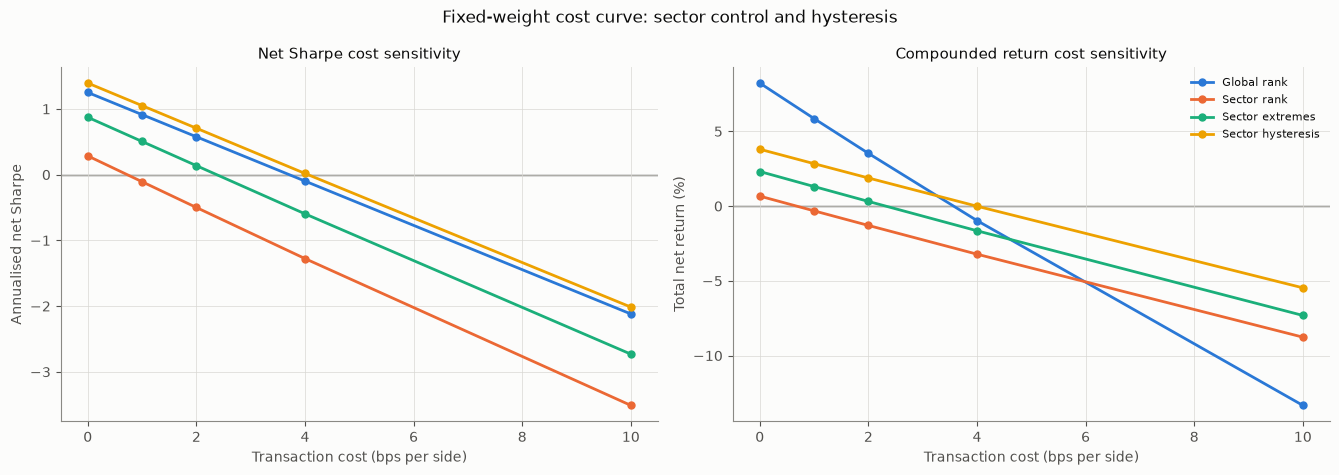

In [8]:
labels = {strategy: display_label(strategy) for strategy in STRATEGY_RULES}
colours = dict(zip(STRATEGY_RULES, CATEGORICAL[: len(STRATEGY_RULES)], strict=True))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for strategy in STRATEGY_RULES:
    curve = cost_curve.loc[cost_curve["strategy"].eq(strategy)]
    axes[0].plot(
        curve["cost_bps_per_side"],
        curve["sharpe_net"],
        marker="o",
        color=colours[strategy],
        label=labels[strategy],
    )
    axes[1].plot(
        curve["cost_bps_per_side"],
        100 * curve["total_net_return"],
        marker="o",
        color=colours[strategy],
        label=labels[strategy],
    )
zero_line(axes[0])
zero_line(axes[1])
axes[0].set(xlabel="Transaction cost (bps per side)", ylabel="Annualised net Sharpe")
axes[1].set(xlabel="Transaction cost (bps per side)", ylabel="Total net return (%)")
axes[0].set_title("Net Sharpe cost sensitivity")
axes[1].set_title("Compounded return cost sensitivity")
axes[1].legend(fontsize=8, loc="best")
fig.suptitle("Fixed-weight cost curve: sector control and hysteresis")
fig.tight_layout()
fig.savefig(OUTPUT / "cost_curve.png", dpi=160, bbox_inches="tight")
plt.show()

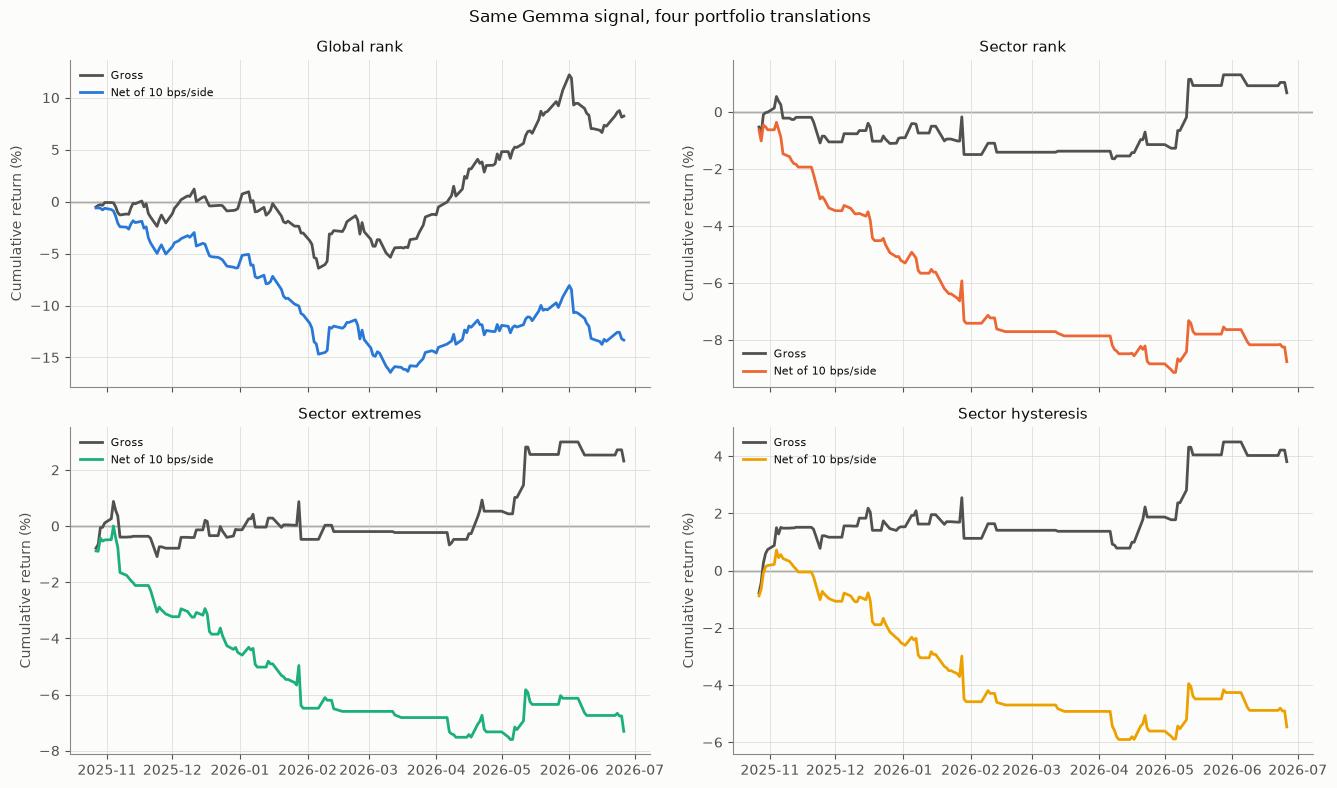

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.0), sharex=True)
for ax, strategy in zip(axes.flat, STRATEGY_RULES, strict=True):
    daily = daily_outputs[strategy]
    gross_equity = (1.0 + daily["gross_return"]).cumprod() - 1.0
    net_equity = (1.0 + daily["net_return"]).cumprod() - 1.0
    ax.plot(daily["session_date"], 100 * gross_equity, color=INK["secondary"], label="Gross")
    ax.plot(
        daily["session_date"],
        100 * net_equity,
        color=colours[strategy],
        label="Net of 10 bps/side",
    )
    zero_line(ax)
    ax.set_title(labels[strategy])
    ax.set_ylabel("Cumulative return (%)")
    ax.legend(fontsize=8)
fig.suptitle("Same Gemma signal, four portfolio translations")
fig.tight_layout()
fig.savefig(OUTPUT / "portfolio_equity.png", dpi=160, bbox_inches="tight")
plt.show()

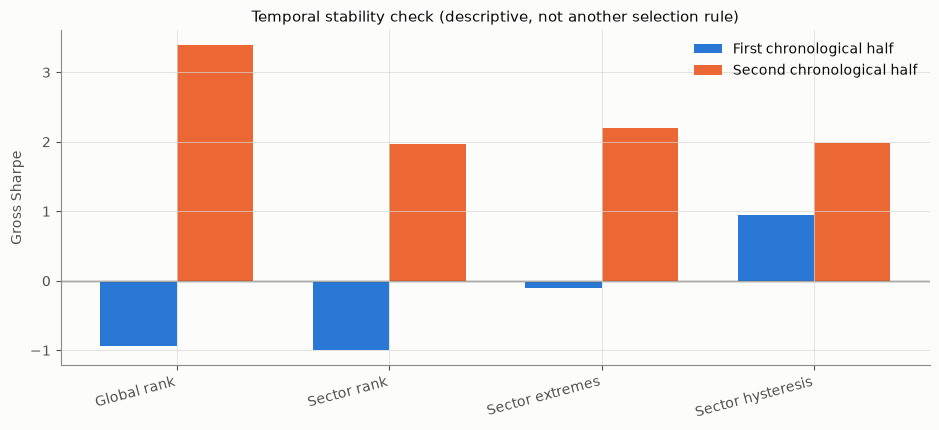

In [10]:
half_table = results[
    ["strategy", "first_half_sharpe_gross", "second_half_sharpe_gross"]
].set_index("strategy")
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(half_table))
width = 0.36
ax.bar(
    x - width / 2,
    half_table["first_half_sharpe_gross"],
    width,
    color=CATEGORICAL[0],
    label="First chronological half",
)
ax.bar(
    x + width / 2,
    half_table["second_half_sharpe_gross"],
    width,
    color=CATEGORICAL[1],
    label="Second chronological half",
)
zero_line(ax)
ax.set_xticks(x, [labels[strategy] for strategy in half_table.index], rotation=15, ha="right")
ax.set_ylabel("Gross Sharpe")
ax.set_title("Temporal stability check (descriptive, not another selection rule)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "temporal_half_sharpe.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Decision

The programmatic gate below is the binding decision. A lower-cost positive
row may be useful as a transaction-cost bound, but it is not promoted as
robust alpha unless the full 10-bps gate passes. Regardless of outcome, this
opened 167-session window is closed to further rule, threshold, and holding-
period tuning; confirmation requires a separately frozen time window.

In [11]:
claim_survivors = results.loc[results["alpha_claim_gate"]]
best_gross = results.sort_values("sharpe_gross", ascending=False).iloc[0]
best_break_even = results.sort_values("breakeven_bps_per_side", ascending=False).iloc[0]
lowest_turnover = results.sort_values("mean_turnover").iloc[0]

decision = {
    "alpha_claim_gate_survivors": int(len(claim_survivors)),
    "bh_gross_mean_survivors": int(results["bh_reject_gross_mean_q05"].sum()),
    "economically_viable_10bps_arms": int(results["economically_viable_10bps"].sum()),
    "best_gross_sharpe_arm": str(best_gross["strategy"]),
    "best_gross_sharpe": float(best_gross["sharpe_gross"]),
    "best_break_even_arm": str(best_break_even["strategy"]),
    "best_break_even_bps_per_side": float(best_break_even["breakeven_bps_per_side"]),
    "lowest_turnover_arm": str(lowest_turnover["strategy"]),
    "lowest_mean_half_l1_turnover": float(lowest_turnover["mean_turnover"]),
    "sector_hysteresis_active_sessions": int(
        results.set_index("strategy").loc["sector_hysteresis", "active_sessions"]
    ),
    "sector_hysteresis_active_session_share": float(
        results.set_index("strategy").loc["sector_hysteresis", "active_session_share"]
    ),
}
display(pd.DataFrame([decision]))
if claim_survivors.empty:
    print("RESULT: no portfolio translation clears the frozen alpha claim gate; preserve the null.")
else:
    print("RESULT: at least one retrospective arm clears the gate; require an untouched confirmation window.")

,alpha_claim_gate_survivors,bh_gross_mean_survivors,economically_viable_10bps_arms,best_gross_sharpe_arm,best_gross_sharpe,best_break_even_arm,best_break_even_bps_per_side,lowest_turnover_arm,lowest_mean_half_l1_turnover,sector_hysteresis_active_sessions,sector_hysteresis_active_session_share
0,0,0,0,sector_hysteresis,1.393313,sector_hysteresis,4.052505,sector_hysteresis,0.280021,57,0.341317


RESULT: no portfolio translation clears the frozen alpha claim gate; preserve the null.


In [12]:
manifest = {
    "status": "RETROSPECTIVE_EXPLORATORY_NON_POOLED_PORTFOLIO_TRANSLATION",
    "signal": {"scorer": "gemma4_26b", "aggregator": "strongest_event", "orientation": 1.0},
    "population": {
        "companies": 44,
        "sectors": 11,
        "priced_firm_opens": int(panel["raw_open_h1"].notna().sum()),
        "entry_sessions": int(panel.loc[panel["raw_open_h1"].notna(), "session_date"].nunique()),
    },
    "sector_map_sources": [
        "configs/lseg_us_sector_33_6m.toml",
        "configs/lseg_us_sector_add11_8m_headlines.toml",
    ],
    "strategies": list(STRATEGY_RULES),
    "portfolio": {
        "outcome": CONFIG.outcome,
        "horizon_sessions": 1,
        "minimum_global_names": CONFIG.min_global_names,
        "minimum_active_sectors": CONFIG.min_active_sectors,
        "cost_bps_per_side": CONFIG.cost_bps_per_side,
        "turnover": "half-L1; cost = 2 x turnover x per-side rate",
        "final_liquidation": True,
    },
    "inference": {
        "multiplicity_family": MULTIPLICITY_FAMILY,
        "block_length_sessions": CONFIG.bootstrap_block_length,
        "replications": CONFIG.bootstrap_replications,
        "seed": CONFIG.random_seed,
    },
    "reference_reproduction": reference_check,
    "activity_matched_diagnostic": activity_diagnostic,
    "strongest_event_resolution": strongest_event_resolution,
    "decision": decision,
    "limitations": [
        "same already-opened eight-month return window as Notebook 13",
        "raw company return is not market-adjusted",
        "fixed current sector classification is a control stratum, not point-in-time sector history",
        "portfolio parameters are return-blind but were proposed after seeing the global strategy null",
        "the six-sector breadth floor leaves only 57 active sessions; the matched-day comparison is post-result diagnostic evidence",
        "Gemma strongest-event is undefined on 47.7% of priced firm-opens because opposing maximum-absolute-score ties trigger abstention",
        "the apparent turnover benefit therefore combines hysteresis with scorer-resolution-induced abstention",
        "no human sentiment-accuracy audit is complete",
        "no result is promoted before Gate F1 or without untouched-window confirmation",
    ],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_EXPLORATORY_NON_POOLED_PORTFOLIO_TRANSLATION",
  "signal": {
    "scorer": "gemma4_26b",
    "aggregator": "strongest_event",
    "orientation": 1.0
  },
  "population": {
    "companies": 44,
    "sectors": 11,
    "priced_firm_opens": 7348,
    "entry_sessions": 167
  },
  "sector_map_sources": [
    "configs/lseg_us_sector_33_6m.toml",
    "configs/lseg_us_sector_add11_8m_headlines.toml"
  ],
  "strategies": [
    "global_rank",
    "sector_rank",
    "sector_extremes",
    "sector_hysteresis"
  ],
  "portfolio": {
    "outcome": "raw_open_h1",
    "horizon_sessions": 1,
    "minimum_global_names": 10,
    "minimum_active_sectors": 6,
    "cost_bps_per_side": 10.0,
    "turnover": "half-L1; cost = 2 x turnover x per-side rate",
    "final_liquidation": true
  },
  "inference": {
    "multiplicity_family": "four return-blind strongest-event portfolio translations x h1; two-sided five-session circular-block mean test; BH-FDR q=0.05",
    "block_length_sess

## Next step

Preserve every arm. If none clears the frozen gate, stop modifying this
eight-month window and treat turnover/cost decomposition as the useful result.
If an arm clears, freeze it unchanged and test it on a later or earlier
untouched LSEG window before making any economic claim. The formal dissertation
priority remains Gate F1 plus the outstanding blinded human audits.